# modify baseline


This notebook runs:
`python -c "<patch torch.load; runpy.run_module('emg2qwerty.train', run_name='__main__')>" user=... dataset.root=...`

It also includes the Windows KenLM optional-import patch. **DataLoader** uses multiple `num_workers` on Windows with `persistent_workers=False` in code so the GPU stays fed; default config uses larger batch + bf16 for higher GPU util.


In [10]:
from __future__ import annotations
import os, sys, subprocess, time, re
from pathlib import Path

REPO_ROOT = Path.cwd()
assert (REPO_ROOT / "emg2qwerty").exists() and (REPO_ROOT / "config").exists(), \
    f"Open this notebook from the emg2qwerty_clean repo root. CWD={REPO_ROOT}"
print("Python:", sys.version.split()[0])
print("Repo root:", REPO_ROOT)


Python: 3.10.20
Repo root: c:\Users\15855\OneDrive\UCLA\course\247A\Project\emg2qwerty


## 1) GPU sanity check


In [11]:
import torch
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if not torch.cuda.is_available():
    raise RuntimeError("CUDA not available in this kernel. Select the emg2qwerty kernel / reinstall CUDA torch.")
print("gpu:", torch.cuda.get_device_name(0))
print("torch CUDA:", torch.version.cuda)


torch: 2.10.0+cu128
cuda available: True
gpu: NVIDIA GeForce RTX 5080
torch CUDA: 12.8


## 2) DATA_DIR

Put the dataset files here:

- `data/subject_89335547/*.hdf5`

This notebook assumes you are running from the repo root, so the full path is:

- `REPO_ROOT / data / subject_89335547`


In [12]:
data_dir = (REPO_ROOT / "data" / "subject_89335547").resolve()

hdf5 = sorted(data_dir.glob("*.hdf5"))
print("Found .hdf5 files:", len(hdf5))

DATA_DIR_HYDRA = str(data_dir).replace("\\", "/")
print("DATA_DIR_HYDRA:", DATA_DIR_HYDRA)

Found .hdf5 files: 18
DATA_DIR_HYDRA: C:/Users/15855/OneDrive/UCLA/course/247A/Project/emg2qwerty/data/subject_89335547


## 3) KenLM (optional)

If you always run with `decoder=ctc_greedy`, you **do not need KenLM** on Windows.
This repo's `emg2qwerty/decoder.py` already treats KenLM as an optional dependency.


In [13]:
# No KenLM setup needed if you use greedy decoding.
# Sanity: this should import even if `kenlm` isn't installed.
import emg2qwerty.decoder  # noqa: F401
print("Import emg2qwerty.decoder: OK")


Import emg2qwerty.decoder: OK


## 4) 1-epoch smoke test training (patch torch.load inside training process)


## Baseline 最优结果（固定参考）

- **训练日志时间**: `2026-03-10/05-44-25`
- **最佳验证集性能 (val)**: `val/CER = 17.63`, `val/loss ≈ 0.7085`（epoch 34 对应的 best checkpoint）
- **测试集性能 (test)**: `test/CER = 21.40`, `test/loss ≈ 0.8145`
- **best checkpoint 路径**:
  - `logs/2026-03-10/05-44-25/checkpoints/epoch=34-step=16800.ckpt`

- **关键超参数（本 baseline 训练配置）**:
  - `EPOCHS = 40`
  - `BATCH_SIZE = 8`
  - `NUM_WORKERS = 10`
  - `optimizer.lr = 5e-4`
  - `lr_scheduler.scheduler.warmup_epochs = 10`
  - `lr_scheduler.scheduler.eta_min = 1e-6`
  - `transforms = log_spectrogram_no_specaug`
  - `decoder = ctc_greedy`
  - `trainer.accelerator = gpu`
  - `trainer.devices = 1`

- **复现实验**: 直接运行上面的长程训练 cell（`EPOCHS = 40` 那一段），即可重现这次 baseline 设定和日志；如需对比改进，请以此 checkpoint 和上述指标作为参考。

In [14]:
from emg2qwerty.notebook_utils import run_and_print

# # Smoke test: use num_workers=1 on Windows — num_workers>0 with HDF5 often crashes workers
# # ("DataLoader worker exited unexpectedly"). Full run cell can use 8 if stable on your machine.
# NUM_WORKERS = 1
# BATCH_SIZE = 8  # increase if no OOM (e.g. 96); decrease if CUDA OOM

# patch_and_run = r'''
# import torch, runpy
# _old = torch.load
# def _patched_load(*args, **kwargs):
#     kwargs.setdefault("weights_only", False)
#     return _old(*args, **kwargs)
# torch.load = _patched_load
# runpy.run_module("emg2qwerty.train", run_name="__main__")
# '''.strip()

# cmd = [
#     sys.executable, "-c", patch_and_run,
#     "user=single_user",
#     f"dataset.root={DATA_DIR_HYDRA}",
#     "trainer.accelerator=gpu", "trainer.devices=1",
#     "trainer.max_epochs=1",
#     "trainer.precision=bf16",
#     f"batch_size={BATCH_SIZE}",
#     f"num_workers={NUM_WORKERS}",
#     "train=True",
#     "decoder=ctc_greedy",
# ]

# t0 = time.time()
# run_and_print(cmd, cwd=REPO_ROOT)
# print(f"OK. Elapsed: {time.time()-t0:.1f}s")


## 5) Full baseline run


In [9]:

EPOCHS = 40
NUM_WORKERS = 10  
BATCH_SIZE = 8
LR = "5e-4"
WARMUP = 10

patch_and_run = r'''
import torch, runpy
# Higher GPU util + faster step time (same fp32 recipe as 03-18-40)
torch.backends.cudnn.benchmark = True
try:
    torch.set_float32_matmul_precision("high")  # TF32 on RTX; small numerical diff possible
except Exception:
    pass
_old = torch.load
def _patched_load(*args, **kwargs):
    kwargs.setdefault("weights_only", False)
    return _old(*args, **kwargs)
torch.load = _patched_load
runpy.run_module("emg2qwerty.train", run_name="__main__")
'''.strip()

cmd = [
    sys.executable, "-c", patch_and_run,
    "user=single_user",
    f"dataset.root={DATA_DIR_HYDRA}",
    "trainer.accelerator=gpu", "trainer.devices=1",
    f"trainer.max_epochs={EPOCHS}",
    f"batch_size={BATCH_SIZE}",
    f"num_workers={NUM_WORKERS}",
    f"optimizer.lr={LR}",
    f"lr_scheduler.scheduler.warmup_epochs={WARMUP}",
    "lr_scheduler.scheduler.eta_min=1e-6",
    "transforms=log_spectrogram_no_specaug",
    "train=True",
    "decoder=ctc_greedy",
]

print(f"Ready. Repro 03-18-40 recipe + fast dataloader, {EPOCHS} ep batch={BATCH_SIZE}:")
print(" ".join(cmd))
run_and_print(cmd, cwd=REPO_ROOT)


Ready. Repro 03-18-40 recipe + fast dataloader, 40 ep batch=8:
c:\Users\15855\.conda\envs\emg2qwerty\python.exe -c import torch, runpy
# Higher GPU util + faster step time (same fp32 recipe as 03-18-40)
torch.backends.cudnn.benchmark = True
try:
    torch.set_float32_matmul_precision("high")  # TF32 on RTX; small numerical diff possible
except Exception:
    pass
_old = torch.load
def _patched_load(*args, **kwargs):
    kwargs.setdefault("weights_only", False)
    return _old(*args, **kwargs)
torch.load = _patched_load
runpy.run_module("emg2qwerty.train", run_name="__main__") user=single_user dataset.root=C:/Users/15855/OneDrive/UCLA/course/247A/Project/emg2qwerty/data/subject_89335547 trainer.accelerator=gpu trainer.devices=1 trainer.max_epochs=40 batch_size=8 num_workers=10 optimizer.lr=5e-4 lr_scheduler.scheduler.warmup_epochs=10 lr_scheduler.scheduler.eta_min=1e-6 transforms=log_spectrogram_no_specaug train=True decoder=ctc_greedy
>> c:\Users\15855\.conda\envs\emg2qwerty\python.exe

TensorBoard scalars not found; falling back to log parse.
Using log: c:\Users\15855\OneDrive\UCLA\course\247A\Project\emg2qwerty\logs\notebook_runs\train_2026-03-10_05-21-08.log


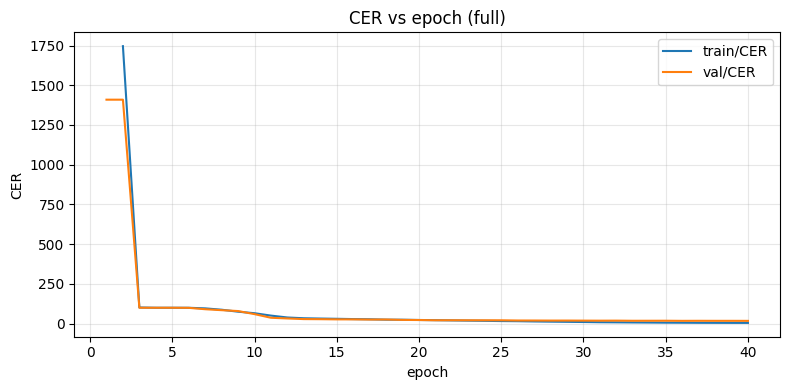

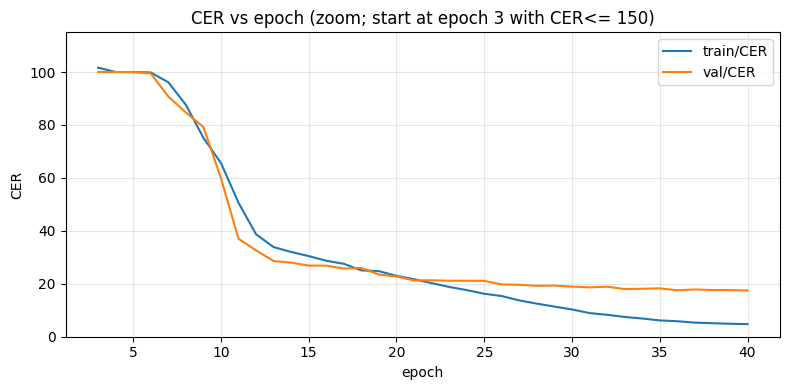

In [8]:
# --- 6) Plot train/val CER across epochs ---
# Preferred source: TensorBoard scalar events (if available)
# Fallback: parse the streamed training log in logs/notebook_runs/train_*.log (always available)

from __future__ import annotations

from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt


def _pick_latest(paths: list[Path]) -> Path:
    if not paths:
        raise FileNotFoundError("No matching files found")
    return max(paths, key=lambda p: p.stat().st_mtime)


def _latest_event_file(logs_root: Path) -> Path | None:
    evs = sorted(logs_root.rglob("events.out.tfevents.*"), key=lambda p: p.stat().st_mtime)
    return evs[-1] if evs else None


def _try_load_tb_scalars(event_file: Path, preferred: list[str]) -> dict[str, tuple[np.ndarray, np.ndarray]]:
    try:
        from tensorboard.backend.event_processing import event_accumulator
    except Exception:
        return {}

    ea = event_accumulator.EventAccumulator(str(event_file), size_guidance={"scalars": 0})
    ea.Reload()
    available = ea.Tags().get("scalars", [])
    out: dict[str, tuple[np.ndarray, np.ndarray]] = {}

    # Some Lightning versions write *_epoch. Prefer the plain names but auto-fallback.
    def resolve(tag: str) -> str | None:
        if tag in available:
            return tag
        alt = f"{tag}_epoch"
        if alt in available:
            return alt
        return None

    for tag in preferred:
        rt = resolve(tag)
        if rt is None:
            continue
        scalars = ea.Scalars(rt)
        steps = np.array([s.step for s in scalars], dtype=np.int64)
        values = np.array([s.value for s in scalars], dtype=np.float64)
        out[tag] = (steps, values)

    return out


def _latest_notebook_run_log(repo_root: Path) -> Path:
    nb_dir = repo_root / "logs" / "notebook_runs"
    logs = list(nb_dir.glob("train_*.log"))
    return _pick_latest(logs)


def _parse_log_train_val_cer(log_path: Path) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    # Train: lines like: [epoch 38] train loss=...  train/CER=5.0874
    re_train = re.compile(r"^\[epoch\s+(\d+)\].*?train/CER=([0-9.]+)")
    # Val (preferred): lines like: [epoch 38] val loss=...  val/CER=17.7005
    re_val_epoch = re.compile(r"^\[epoch\s+(\d+)\].*?val/CER=([0-9.]+)")
    # Val (fallback): only when best improves (older logs)
    re_val_best = re.compile(r"^Epoch\s+(\d+),.*?val/CER.*?reached\s+([0-9.]+)")

    train: dict[int, float] = {}
    val: dict[int, float] = {}

    for line in log_path.read_text(encoding="utf-8", errors="ignore").splitlines():
        m = re_train.match(line)
        if m:
            ep = int(m.group(1))
            train[ep] = float(m.group(2))
            continue
        m = re_val_epoch.match(line)
        if m:
            ep = int(m.group(1))
            val[ep] = float(m.group(2))
            continue
        m = re_val_best.match(line)
        if m and int(m.group(1)) not in val:
            ep = int(m.group(1))
            val[ep] = float(m.group(2))
            continue

    if not train and not val:
        raise ValueError(f"Could not parse train/val CER from log: {log_path}")

    # Use union of epochs and align; display as 1-based epochs
    eps = sorted(set(train.keys()) | set(val.keys()))
    x = np.array([e + 1 for e in eps], dtype=np.int64)
    train_y = np.array([train.get(e, np.nan) for e in eps], dtype=np.float64)
    val_y = np.array([val.get(e, np.nan) for e in eps], dtype=np.float64)
    return x, train_y, val_y


logs_root = REPO_ROOT / "logs"

event_file = _latest_event_file(logs_root)
scalars: dict[str, tuple[np.ndarray, np.ndarray]] = {}
if event_file is not None:
    scalars = _try_load_tb_scalars(event_file, ["train/CER", "val/CER"])

if scalars.get("train/CER") is not None or scalars.get("val/CER") is not None:
    print("Using TensorBoard event:", event_file)
    x_train, y_train = scalars.get("train/CER", (np.array([], dtype=np.int64), np.array([], dtype=np.float64)))
    x_val, y_val = scalars.get("val/CER", (np.array([], dtype=np.int64), np.array([], dtype=np.float64)))

    # If steps look like 0..N-1, show as epoch index + 1
    def _epochify(x: np.ndarray) -> np.ndarray:
        if x.size == 0:
            return x
        if x.min() == 0 and np.all(np.diff(x) >= 0) and x.max() < 10_000:
            return x + 1
        return x

    x_train = _epochify(x_train)
    x_val = _epochify(x_val)

    plt.figure(figsize=(8, 4))
    if y_train.size:
        plt.plot(x_train, y_train, label="train/CER")
    if y_val.size:
        plt.plot(x_val, y_val, label="val/CER")
    plt.title("CER vs epoch")
    plt.xlabel("epoch")
    plt.ylabel("CER")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    # Fallback: parse the streamed notebook log (this is what you see printed during training)
    log_path = _latest_notebook_run_log(REPO_ROOT)
    print("TensorBoard scalars not found; falling back to log parse.")
    print("Using log:", log_path)

    x, train_y, val_y = _parse_log_train_val_cer(log_path)

    # --- Plot 1: full curve (all epochs) ---
    plt.figure(figsize=(8, 4))
    plt.plot(x, train_y, label="train/CER")
    plt.plot(x, val_y, label="val/CER")
    plt.title("CER vs epoch (full)")
    plt.xlabel("epoch")
    plt.ylabel("CER")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Plot 2: zoomed curve (skip early exploding CER) ---
    # Heuristic: find the first epoch where BOTH train+val are <= threshold,
    # then plot from there. This keeps late-epoch changes visible.
    threshold = 150.0
    ok = np.isfinite(train_y) & np.isfinite(val_y) & (train_y <= threshold) & (val_y <= threshold)
    start_idx = int(np.argmax(ok)) if np.any(ok) else 0

    x2 = x[start_idx:]
    train2 = train_y[start_idx:]
    val2 = val_y[start_idx:]

    plt.figure(figsize=(8, 4))
    plt.plot(x2, train2, label="train/CER")
    plt.plot(x2, val2, label="val/CER")
    plt.title(f"CER vs epoch (zoom; start at epoch {int(x2[0])} with CER<= {threshold:g})" if x2.size else "CER vs epoch (zoom)")
    plt.xlabel("epoch")
    plt.ylabel("CER")
    plt.grid(True, alpha=0.3)
    plt.legend()

    # Set a tighter y-limit based on the zoomed segment
    all2 = np.concatenate([train2[np.isfinite(train2)], val2[np.isfinite(val2)]])
    if all2.size:
        hi2 = float(np.nanpercentile(all2, 95))
        plt.ylim(0, max(10.0, hi2 * 1.15))

    plt.tight_layout()
    plt.show()


In [ ]:
# === Run original baseline config (match Calvin Pang repo) ===
# This cell runs the official baseline training using the SAME Hydra
# config as the original repo (single_user + log_spectrogram + tds_conv_ctc
# + adam + linear_warmup_cosine_annealing, etc.).
# 等价于在命令行里执行：
#   python -m emg2qwerty.train \
#       user=single_user \
#       dataset.root=../data/subject_89335547 \
#       trainer.max_epochs=40 \
#       num_workers=4 \
#       train=True \
#       decoder=ctc_greedy \
#       trainer.accelerator=gpu \
#       trainer.devices=1

import os
import sys
import runpy
from pathlib import Path

import torch

# 仓库根目录（当前 notebook 就在根目录里）
REPO_ROOT = Path.cwd().resolve()
os.chdir(REPO_ROOT)

# 数据目录：保持和原 repo 一致；如果你数据不在这里，可以改这个路径
DATA_DIR = REPO_ROOT / "data" / "subject_89335547"

# 构造和原 repo 完全一致的 Hydra 参数
argv = [
    "emg2qwerty.train",
    "user=single_user",
    f"dataset.root={DATA_DIR.as_posix()}",
    "trainer.max_epochs=40",
    "num_workers=4",
    "train=True",
    "decoder=ctc_greedy",
    "trainer.accelerator=gpu",
    "trainer.devices=1",
]

print("Running baseline with argv:")
print(" ", " ".join(argv))

# 兼容新的 torch.load(weights_only=True) 行为（和 Windows 脚本一致）
_old_torch_load = torch.load

def _patched_load(*a, **k):
    k = dict(k)
    k.setdefault("weights_only", False)
    return _old_torch_load(*a, **k)

torch.load = _patched_load

# 设置 sys.argv 并直接以 __main__ 方式运行训练模块
sys.argv = argv
runpy.run_module("emg2qwerty.train", run_name="__main__")


Launching original baseline run via:
  powershell -ExecutionPolicy Bypass -File C:\Users\15855\OneDrive\UCLA\course\247A\Project\emg2qwerty\scripts\run_train_windows.ps1 -MaxEpochs 40

Baseline run finished with return code: 0
